In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [3]:
from src.data_loader import load_conll

In [5]:
df = load_conll("../data/hinglish_train.txt")

In [6]:
df.head()

,tweet_id,sentiment,text
0,3,negative,@ AdilNisarButt pakistan ka ghra tauq he Pakis...
1,41,negative,Madarchod mulle ye mathura me Nahi dikha tha j...
2,48,positive,@ narendramodi Manya Pradhan Mantri mahoday Sh...
3,64,positive,@ Atheist _ Krishna Jcb full trend me chal rah...
4,66,positive,@ AbhisharSharma _ @ RavishKumarBlog Loksabha ...


In [7]:
df.shape

(15131, 3)

In [9]:
import matplotlib.pyplot as plt

In [10]:
sentiment_counts = df["sentiment"].value_counts()

print(sentiment_counts)

sentiment
neutral     5638
positive    5034
negative    4459
Name: count, dtype: int64


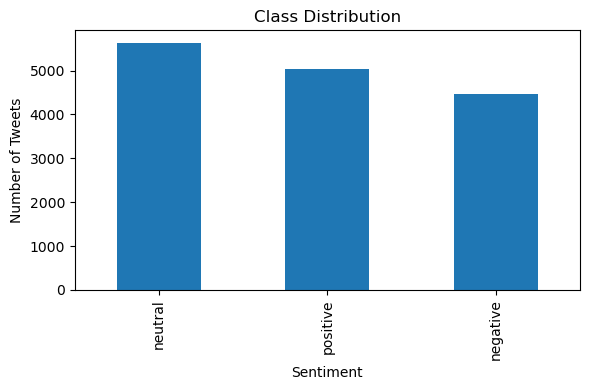

In [16]:
plt.figure(figsize=(6,4))

sentiment_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.savefig("../results/class_distribution.png")
plt.show()

In [17]:
df["tweet_length"] = df["text"].apply(lambda x: len(x.split()))

In [18]:
df[["text", "tweet_length"]].head()

,text,tweet_length
0,@ AdilNisarButt pakistan ka ghra tauq he Pakis...,20
1,Madarchod mulle ye mathura me Nahi dikha tha j...,32
2,@ narendramodi Manya Pradhan Mantri mahoday Sh...,25
3,@ Atheist _ Krishna Jcb full trend me chal rah...,11
4,@ AbhisharSharma _ @ RavishKumarBlog Loksabha ...,32


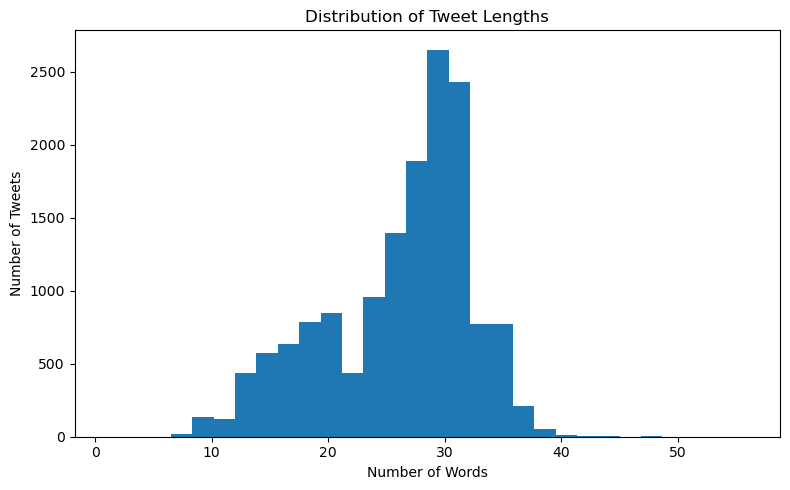

In [19]:
plt.figure(figsize=(8,5))

plt.hist(df["tweet_length"], bins=30)

plt.title("Distribution of Tweet Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Tweets")

plt.tight_layout()

plt.savefig("../results/tweet_length_distribution.png")

plt.show()

In [20]:
print("Average length:", df["tweet_length"].mean())
print("Median length:", df["tweet_length"].median())
print("Max length:", df["tweet_length"].max())
print("Min length:", df["tweet_length"].min())

Average length: 26.17262573524552
Median length: 28.0
Max length: 56
Min length: 1


In [21]:
with open("../data/hinglish_train.txt", "r", encoding="utf-8") as f:
    for _ in range(20):
        print(f.readline())

meta	3	negative

@	O

AdilNisarButt	Hin

pakistan	Hin

ka	Hin

ghra	Hin

tauq	Hin

he	Eng

Pakistan	Eng

Israel	Eng

ko	Eng

tasleem	Hin

nahein	Hin

kerta	Hin

Isko	Hin

Palestine	Hin

kehta	Hin

he	Hin

-	O

OCCUPIED	Hin



In [22]:
from collections import Counter

lang_counts = Counter()

In [23]:
with open("../data/hinglish_train.txt", "r", encoding="utf-8") as f:

    for line in f:

        line = line.strip()

        if not line:
            continue

        parts = line.split("\t")

        if parts[0] == "meta":
            continue

        if len(parts) >= 2:
            lang = parts[1]
            lang_counts[lang] += 1

In [24]:
print(lang_counts)

Counter({'Hin': 184546, 'Eng': 130827, 'O': 80069, 'EMT': 543})


In [27]:
import pandas as pd
lang_df = pd.DataFrame(
    lang_counts.items(),
    columns=["Language", "Count"]
)

lang_df

,Language,Count
0,O,80069
1,Hin,184546
2,Eng,130827
3,EMT,543


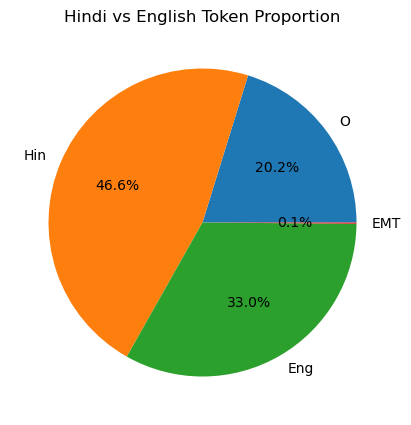

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.pie(
    lang_df["Count"],
    labels=lang_df["Language"],
    autopct="%1.1f%%"
    )
plt.title("Hindi vs English Token Proportion")

plt.savefig("../results/language_proportion.png")
plt.show()

In [36]:
df["sentiment"].value_counts()

sentiment
neutral     5638
positive    5034
negative    4459
Name: count, dtype: int64

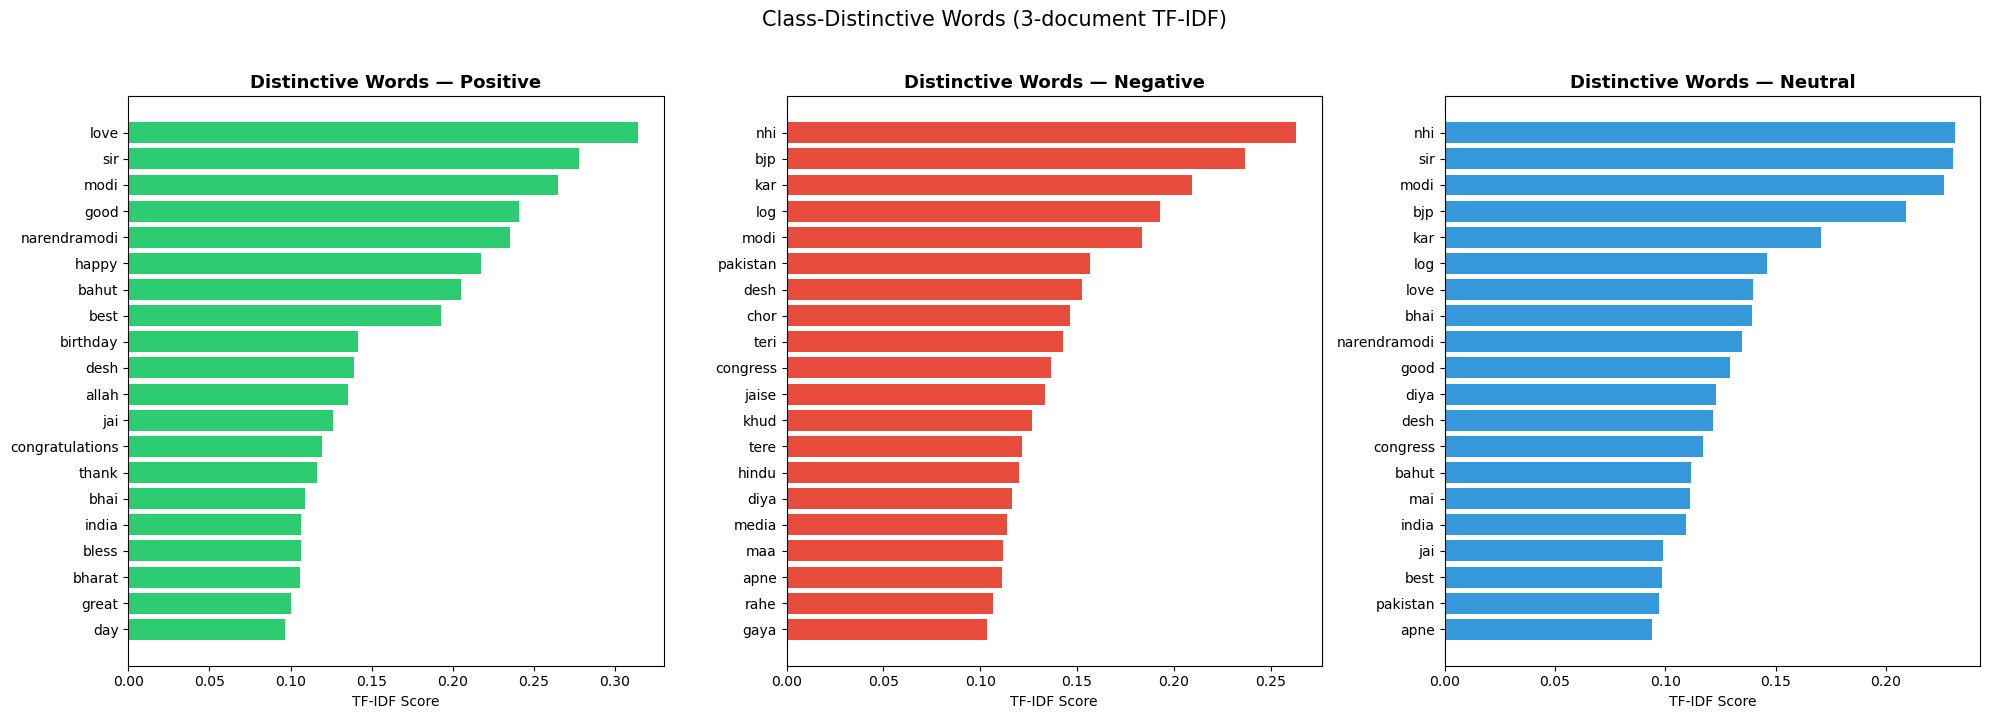

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import re

# ---- Clean function (Hindi + English stopwords) ----
HINDI_STOPS = {
    'hai', 'hain', 'ka', 'ki', 'ke', 'ko', 'me', 'se',
    'aur', 'bhi', 'nahi', 'koi', 'toh', 'yeh', 'wo',
    'kya', 'tha', 'thi', 'the', 'ek', 'ho', 'na', 'hi',
    'jo', 'ab', 'ye', 'woh', 'par', 'ne', 'mein', 'hoga',
    'raha', 'rahi', 'kuch', 'apna', 'apni', 'agar', 'bas',
    'mat', 'jab', 'tab', 'iss', 'us', 'unka', 'uska', 'hua',
    'hui', 'hue', 'tum', 'main', 'mujhe', 'aap', 'mere'
}

def clean(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)      # URLs
    text = re.sub(r'@\w+', '', text)         # mentions
    text = re.sub(r'#\w+', '', text)         # hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text) # punctuation/numbers
    tokens = [t for t in text.split() 
              if t not in HINDI_STOPS and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean)

# ---- Merge each class into one mega-document ----
classes = ['positive', 'negative', 'neutral']

class_docs = [
    ' '.join(df[df['sentiment'] == c]['clean_text'])
    for c in classes
]

# ---- Fit TF-IDF on 3 documents (one per class) ----
# Now IDF = low for words appearing in all 3 classes
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',   # catches remaining English stops
    min_df=1
)

tfidf_matrix = vectorizer.fit_transform(class_docs)
words = vectorizer.get_feature_names_out()

# ---- Plot for each class ----
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, (cls, ax) in enumerate(zip(classes, axes)):
    scores = np.asarray(tfidf_matrix[i].todense()).flatten()
    
    top_idx = scores.argsort()[::-1][:20]
    top_words = words[top_idx]
    top_scores = scores[top_idx]
    
    ax.barh(top_words[::-1], top_scores[::-1], color=['#2ecc71','#e74c3c','#3498db'][i])
    ax.set_title(f'Distinctive Words — {cls.capitalize()}', fontsize=13, fontweight='bold')
    ax.set_xlabel('TF-IDF Score')

plt.suptitle('Class-Distinctive Words (3-document TF-IDF)', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../results/top_tfidf_words_per_class.png', bbox_inches='tight', dpi=150)
plt.show()